# Florida county-level shocks — investigating `shocks preprocess` / `shocks assemble`

This notebook **imports**
`src/regions/florida/sources/shocks/{preprocess,assemble}.py` — the way
`schools.ipynb`/`assessments.ipynb` do — runs each stage, and walks through
the main data-preparation decisions with the real fetched OpenFEMA data
(already on disk). Full design brief:
[`docs/data/florida/shocks/README.md`](../../../docs/data/florida/shocks/README.md).

| file | grain | written by |
|---|---|---|
| `processed/disaster_declarations.parquet` | one row per raw declaration | `preprocess` |
| `assembled/school_shocks_panel.parquet` | one row per `county_name x assessment_year` | `assemble` |

Covariate Cluster G: county-level shocks (hurricanes, severe weather)
disrupt schooling independent of any noise wall. v1 scope is the
hurricane/disaster-declaration variable only (OpenFEMA
`DisasterDeclarationsSummaries`) — three decisions drove its design, each
with the real data behind it below: (1) the entire FL disaster-declaration
history fetches in one request, no pagination; (2) the county join is a
name match against FLDOE's district roster, not a FIPS crosswalk table,
because Florida has exactly one school district per county; (3)
`assessment_year` is a documented month-aware modeling assumption, not a
guess.

Run with the `311` conda env (geopandas, pandas 3).

In [1]:
import json
import geopandas as gpd

import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREEN, GREY, ORANGE, RED, np, pd, plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

from src.regions.florida.sources.shocks import preprocess as PRE               # noqa: E402
from src.regions.florida.sources.shocks import assemble as ASM                 # noqa: E402
from src.regions.florida.sources.shocks import shared as SH                    # noqa: E402

FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print("  saved", path.relative_to(ROOT))


ROOT

PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution')

## 1. The raw OpenFEMA extract: one request, no pagination

Confirmed live before building `fetch.py`: `$top=5000` returns every
Florida `DisasterDeclarationsSummaries` row in one response.

In [2]:
raw = PRE.load_raw_disaster_declarations()
print(f"{len(raw):,} rows, {raw.shape[1]} columns")
print("\nincidentType counts:")
print(raw["incidentType"].value_counts())
print("\ndeclarationType counts:")
print(raw["declarationType"].value_counts())
raw[["disasterNumber", "declarationType", "incidentType", "declarationDate", "designatedArea"]].head(5)

2,794 rows, 29 columns

incidentType counts:
incidentType
Hurricane         1432
Severe Storm       376
Fire               280
Tropical Storm     266
Biological         150
Freezing           147
Flood               74
Tornado             38
Coastal Storm       25
Human Cause          4
Other                2
Name: count, dtype: int64

declarationType counts:
declarationType
DR    1629
EM    1004
FM     161
Name: count, dtype: int64


,disasterNumber,declarationType,incidentType,declarationDate,designatedArea
0,5632,FM,Fire,2026-04-23T00:00:00.000Z,Levy (County)
1,5631,FM,Fire,2026-04-22T00:00:00.000Z,Clay (County)
2,5631,FM,Fire,2026-04-22T00:00:00.000Z,Putnam (County)
3,5426,FM,Fire,2022-03-06T00:00:00.000Z,Bay (County)
4,5426,FM,Fire,2022-03-06T00:00:00.000Z,Calhoun (County)


## 2. The county join is a NAME match, not FIPS

`designatedArea` is a county-name string (`"Broward (County)"`), not just a
FIPS code. Florida has exactly one school district per county — checked
directly against `school_cross_section.parquet` before designing the join
this way.

In [3]:
cross_section = ASM.load_school_cross_section(ROOT)
district_names = ASM.real_county_names(cross_section)
print(f"real (1-67) FLDOE county-districts: {len(district_names)}")

areas = sorted(raw["designatedArea"].dropna().unique())
print(f"\ndistinct designatedArea values in the raw OpenFEMA extract: {len(areas)}")

normalized = SH.normalize_county_name(raw["designatedArea"])
matches_a_county = normalized.isin(set(district_names))
is_statewide = normalized.eq(SH.STATEWIDE_AREA)
unmapped = normalized[~matches_a_county & ~is_statewide]
print(f"rows matching a real county:  {matches_a_county.sum():,}")
print(f"rows flagged Statewide:       {is_statewide.sum():,}")
print(f"rows unmapped (tribal/trust land, not a county): {unmapped.nunique()} distinct areas, "
      f"{len(unmapped):,} rows")
print("\nunmapped area names:", sorted(unmapped.unique()))

real (1-67) FLDOE county-districts: 67

distinct designatedArea values in the raw OpenFEMA extract: 79
rows matching a real county:  2,705
rows flagged Statewide:       24
rows unmapped (tribal/trust land, not a county): 10 distinct areas, 65 rows

unmapped area names: ['BIG CYPRESS INDIAN RESERVATION', 'BRIGHTON INDIAN RESERVATION', 'FLORIDA TRIBE OF EASTERN CREEK (TDSA)', 'FORT PIERCE INDIAN RESERVATION', 'HOLLYWOOD INDIAN RESERVATION', 'IMMOKALEE INDIAN RESERVATION', 'MICCOSUKEE TRIBE OF INDIANS OF FLORIDA', 'POARCH CREEK RESERVATION AND TRUST LANDS (ALSO AL)', 'SEMINOLE TRIBE OF FLORIDA', 'TAMPA RESERVATION']


One naming alias was needed: `"Dade (County)"` (the pre-1997 name) still
appears on older declarations alongside the current `"Miami-Dade (County)"`
— `normalize_county_name` maps `DADE -> MIAMI-DADE` explicitly.
`"Statewide"` is a real signal (unioned into every county's rollup, §4),
not dropped; the 10 tribal-reservation/trust-land names don't map to any
FLDOE district and are excluded from the per-county rollup, but kept in the
processed table rather than silently discarded.

## 3. `assessment_year`: a documented month-aware assumption

Mirrors `schools/preprocess.py`'s `in_operation` rule
(`open_spring = year + (month >= 7)`): a declaration in the second half of
the calendar year (hurricane season + fall semester) is attributed to the
*following* spring's assessment year.

In [4]:
example = pd.DataFrame({
    "declaration_date": pd.to_datetime(["2017-09-10", "2016-01-15", "2016-06-30", "2016-07-01"]),
})
example["assessment_year"] = example["declaration_date"].dt.year + (example["declaration_date"].dt.month >= 7).astype(int)
example

,declaration_date,assessment_year
0,2017-09-10,2018
1,2016-01-15,2016
2,2016-06-30,2016
3,2016-07-01,2017


## 4. Run the full `preprocess` (validates + persists)

In [5]:
report = PRE.run_shocks_preprocess()
print(json.dumps({k: v for k, v in report.items() if k not in ("saved",)}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))

{
 "raw_rows": 2794,
 "rows": 2794,
 "hurricane_rows": 1432,
 "statewide_rows": 24,
 "assessment_year_range": [
  1954,
  2026
 ],
 "columns": [
  "disaster_number",
  "fema_declaration_string",
  "declaration_type",
  "incident_type",
  "declaration_title",
  "declaration_date",
  "assessment_year",
  "is_hurricane",
  "is_statewide",
  "county_name",
  "designated_area_raw",
  "fips_county_code",
  "incident_begin_date",
  "incident_end_date"
 ]
}
wrote data/florida/shocks/processed/disaster_declarations.parquet
wrote data/florida/shocks/processed/shocks.json


## 5. County-year rollup + `Statewide` expansion (`assemble`)

Output grain is `county_name x assessment_year`, deliberately **not**
exploded to `msid x year` — every school in a county sees identical
declaration history, so a per-school file would just multiply a
~1,774-row table by ~7,000 schools for zero new information.
`build_county_year_panel` expands each `Statewide` row across every real
county before aggregating, so a county's counts reflect both its own
county-specific declarations and any statewide ones.

In [6]:
processed = pd.read_parquet(SH.processed_declarations_path(ROOT))
panel = ASM.build_county_year_panel(processed, district_names)

print(f"county-year rows: {len(panel):,}")
print(f"distinct counties represented: {panel['county_name'].nunique()} of {len(district_names)}")

example_county = "BROWARD"
example_year = 2018
row = panel[(panel["county_name"] == example_county) & (panel["assessment_year"] == example_year)]
print(f"\n{example_county} {example_year}:")
print(row.to_string(index=False))

county-year rows: 1,774
distinct counties represented: 67 of 67

BROWARD 2018:
county_name  assessment_year  n_declarations  n_hurricane_declarations  any_major_disaster
    BROWARD             2018               2                         2                True


A county's row for a year with only a `Statewide` declaration (no
county-specific one) still shows `n_declarations >= 1` — confirming the
expansion actually reaches every county, not just the ones with their own
named declaration that year.

## 6. Run the full `assemble` (validates + persists)

In [7]:
report = ASM.run_shocks_assemble(root=ROOT)
print(json.dumps({k: v for k, v in report.items() if k not in ("saved",)}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))

{
 "generated_at_utc": "2026-09-17T11:51:47+00:00",
 "generated_by": "src/regions/florida/sources/shocks/assemble.py",
 "distinct_counties": 67,
 "county_year_panel_rows": 1774,
 "counties_with_a_declaration": 67,
 "unmapped_county_rows": 65,
 "unmapped_county_names": [
  "BIG CYPRESS INDIAN RESERVATION",
  "BRIGHTON INDIAN RESERVATION",
  "FLORIDA TRIBE OF EASTERN CREEK (TDSA)",
  "FORT PIERCE INDIAN RESERVATION",
  "HOLLYWOOD INDIAN RESERVATION",
  "IMMOKALEE INDIAN RESERVATION",
  "MICCOSUKEE TRIBE OF INDIANS OF FLORIDA",
  "POARCH CREEK RESERVATION AND TRUST LANDS (ALSO AL)",
  "SEMINOLE TRIBE OF FLORIDA",
  "TAMPA RESERVATION"
 ]
}
wrote data/florida/shocks/assembled/school_shocks_panel.parquet


  saved output/figures/florida/shocks_hurricane_declarations_by_year.png


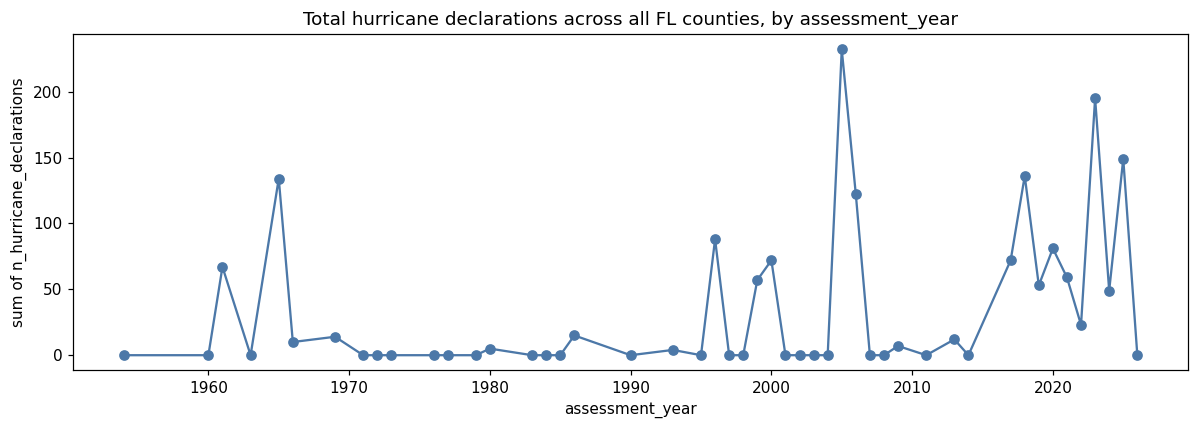

In [8]:
county_year_panel = pd.read_parquet(SH.school_shocks_panel_path(ROOT))
by_year = county_year_panel.groupby("assessment_year")["n_hurricane_declarations"].sum()

fig, ax = plt.subplots(figsize=(11, 4))
by_year.plot(ax=ax, marker="o", color=BLUE)
ax.set_title("Total hurricane declarations across all FL counties, by assessment_year")
ax.set_xlabel("assessment_year")
ax.set_ylabel("sum of n_hurricane_declarations")
fig.tight_layout()
savefig(fig, "shocks_hurricane_declarations_by_year.png")
plt.show()

Spikes line up with named storms hitting many counties at once (2004
quad, 2005 Wilma, 2017 Irma, 2018 Michael) rather than a smooth trend —
consistent with disaster declarations being discrete, storm-driven events,
not a slowly-varying county characteristic.

## Notes & next steps

- **Class-Size-Reduction compliance (2003-2010)** and **School Grades
  archives** — both FLDOE per-year Excel exports, no REST API found;
  expect similar scripted-client friction to `assessments/fetch.py`. Not
  researched — flagged as a follow-up brief of its own.
- **Storm track / wind swath (NOAA HURDAT2/IBTrACS)** — finer-than-county
  exposure, a genuine stretch goal; left unbuilt.
- **Test regime, COVID 2020/2021, test participation rate** — no new
  source needed; already live in `assessments.parquet`, pure
  analysis-layer decisions per `covariates.md`.
- Joined into `panel/assemble.py`'s `event_study_panel.parquet` via an
  exact `(district_name, year)` match (`attach_shocks`) — the simplest join
  of the three covariate modules built this session, since `shocks
  assemble` already resolves each declaration to one exact county+year.